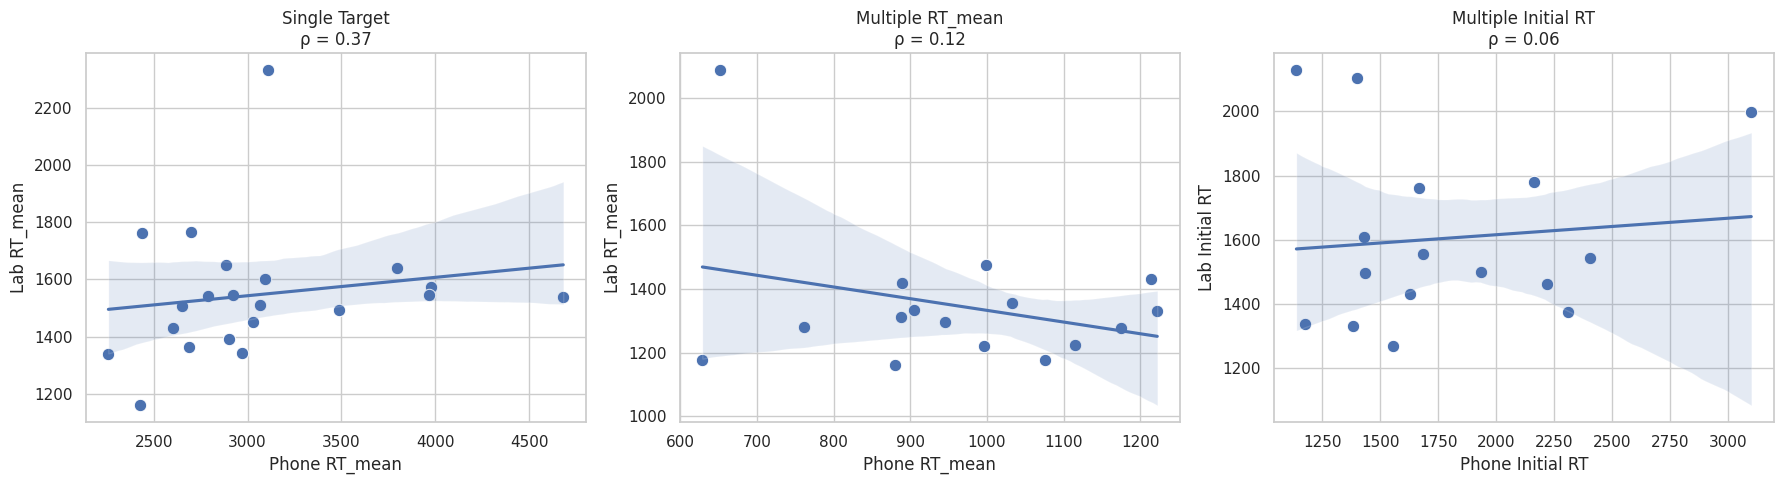

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set(style="whitegrid")

file_path = "/home/hp/Documents/BRSM/data_brsm/Combined.csv"
df = pd.read_csv(file_path)
df["modality"] = df["modality"].str.strip()
df["target_load"] = df["target_load"].str.strip()
fig, axes = plt.subplots(1,3, figsize=(18,5))
single_players = list(range(1,22))

single = df[
    (df["target_load"]=="Single") &
    (df["participant"].isin(single_players))
]

single_avg = (
    single.groupby(["participant","modality"])["RT_mean(ms)"]
    .mean()
    .reset_index()
)

single_rt = single_avg.pivot(
    index="participant",
    columns="modality",
    values="RT_mean(ms)"
).dropna()

if "Phone" in single_rt.columns and "Lab" in single_rt.columns:

    rho_single, _ = spearmanr(single_rt["Phone"], single_rt["Lab"])

    sns.scatterplot(
        x=single_rt["Phone"],
        y=single_rt["Lab"],
        ax=axes[0],
        s=80
    )

    sns.regplot(
        x=single_rt["Phone"],
        y=single_rt["Lab"],
        ax=axes[0],
        scatter=False
    )

    axes[0].set_title(f"Single Target\nρ = {rho_single:.2f}")
    axes[0].set_xlabel("Phone RT_mean")
    axes[0].set_ylabel("Lab RT_mean")

multi_players = list(range(22,38))

multi = df[
    (df["target_load"]=="Multiple") &
    (df["participant"].isin(multi_players))
]

multi_avg = (
    multi.groupby(["participant","modality"])
    [["RT_mean(ms)","Initial_RT(ms)"]]
    .mean()
    .reset_index()
)

multi_rt = multi_avg.pivot(
    index="participant",
    columns="modality",
    values="RT_mean(ms)"
).dropna()

multi_init = multi_avg.pivot(
    index="participant",
    columns="modality",
    values="Initial_RT(ms)"
).dropna()

if "Phone" in multi_rt.columns and "Lab" in multi_rt.columns:

    rho_multi_rt, _ = spearmanr(multi_rt["Phone"], multi_rt["Lab"])

    sns.scatterplot(
        x=multi_rt["Phone"],
        y=multi_rt["Lab"],
        ax=axes[1],
        s=80
    )

    sns.regplot(
        x=multi_rt["Phone"],
        y=multi_rt["Lab"],
        ax=axes[1],
        scatter=False
    )

    axes[1].set_title(f"Multiple RT_mean\nρ = {rho_multi_rt:.2f}")
    axes[1].set_xlabel("Phone RT_mean")
    axes[1].set_ylabel("Lab RT_mean")


if "Phone" in multi_init.columns and "Lab" in multi_init.columns:

    rho_multi_init, _ = spearmanr(multi_init["Phone"], multi_init["Lab"])

    sns.scatterplot(
        x=multi_init["Phone"],
        y=multi_init["Lab"],
        ax=axes[2],
        s=80
    )

    sns.regplot(
        x=multi_init["Phone"],
        y=multi_init["Lab"],
        ax=axes[2],
        scatter=False
    )

    axes[2].set_title(f"Multiple Initial RT\nρ = {rho_multi_init:.2f}")
    axes[2].set_xlabel("Phone Initial RT")
    axes[2].set_ylabel("Lab Initial RT")


plt.tight_layout()
plt.show()